Usando dispositivo: cpu
Total imágenes: 2499
Train: 1749 | Val: 374 | Test: 376
Clases: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

Iniciando entrenamiento: S0_no_aug

Época 1/10
------------------------------
TRAIN | Loss: 1.3256 | Acc: 0.5106
VAL   | Loss: 0.9997 | Acc: 0.6578

Época 2/10
------------------------------
TRAIN | Loss: 0.8444 | Acc: 0.7284
VAL   | Loss: 0.7763 | Acc: 0.7246

Época 3/10
------------------------------
TRAIN | Loss: 0.7364 | Acc: 0.7530
VAL   | Loss: 0.6842 | Acc: 0.7781

Época 4/10
------------------------------
TRAIN | Loss: 0.6313 | Acc: 0.7885
VAL   | Loss: 0.6591 | Acc: 0.7727

Época 5/10
------------------------------
TRAIN | Loss: 0.5718 | Acc: 0.8102
VAL   | Loss: 0.6115 | Acc: 0.7968

Época 6/10
------------------------------
TRAIN | Loss: 0.5529 | Acc: 0.8130
VAL   | Loss: 0.5848 | Acc: 0.8048

Época 7/10
------------------------------
TRAIN | Loss: 0.5049 | Acc: 0.8285
VAL   | Loss: 0.5749 | Acc: 0.8048

Época 8/10
------------

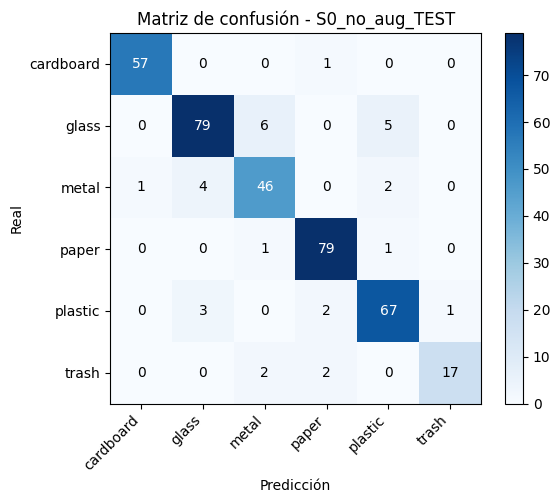

Accuracy final en TEST: 0.9175531914893617


In [3]:
# ESCENARIO S0 - SIN DATA AUGMENTATION (BASELINE)

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import numpy as np

# CONFIGURACIÓN GENERAL

data_dir = r"C:\Users\soria\Downloads\Metodología\Clasificacion_residuos"
os.makedirs("Modelos2", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

# TRANSFORMACIONES (SIN AUGMENTATION)

basic_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# FUNCIÓN: CARGA Y SPLIT DEL DATASET (70/15/15)

def cargar_y_dividir_dataset(ruta_carpeta, seed=42):
    """
    Carga un dataset ImageFolder y lo divide en:
    70% entrenamiento, 15% validación y 15% prueba.
    No se utiliza data augmentation.
    """
    full_dataset = datasets.ImageFolder(
        ruta_carpeta,
        transform=basic_transforms
    )

    total = len(full_dataset)
    train_size = int(0.7 * total)
    val_size = int(0.15 * total)
    test_size = total - train_size - val_size

    torch.manual_seed(seed)
    train_ds, val_ds, test_ds = random_split(
        full_dataset,
        [train_size, val_size, test_size]
    )

    train_loader = DataLoader(
        train_ds, batch_size=32, shuffle=True, num_workers=2
    )
    val_loader = DataLoader(
        val_ds, batch_size=32, shuffle=False, num_workers=2
    )
    test_loader = DataLoader(
        test_ds, batch_size=32, shuffle=False, num_workers=2
    )

    class_names = full_dataset.classes

    print(f"Total imágenes: {total}")
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    print(f"Clases: {class_names}")

    return {
        "train": train_loader,
        "val": val_loader,
        "test": test_loader
    }, class_names

# FUNCIÓN: CREACIÓN DEL MODELO (RESNET-18)

def crear_modelo_resnet18(num_classes):
    model = models.resnet18(weights="IMAGENET1K_V1")

    # Fase 1: congelar capas convolucionales
    for param in model.parameters():
        param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model.to(device)

# FUNCIÓN: ENTRENAMIENTO

def train_model(model, criterion, optimizer, dataloaders, dataset_sizes,
                escenario="S0_no_aug", num_epochs=10):

    best_acc = 0.0
    best_wts = model.state_dict()

    print(f"\nIniciando entrenamiento: {escenario}")

    for epoch in range(num_epochs):
        print(f"\nÉpoca {epoch+1}/{num_epochs}")
        print("-" * 30)

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase.upper():<5} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_wts = model.state_dict()

    model.load_state_dict(best_wts)

    model_path = f"Modelos2/resnet18_{escenario}.pth"
    torch.save(model.state_dict(), model_path)

    print(f"\nModelo guardado en: {model_path}")
    print(f"Mejor accuracy de validación: {best_acc:.4f}")

    return model

# FUNCIÓN: EVALUACIÓN EN TEST

def evaluar_en_test(model, test_loader, class_names, escenario="S0_no_aug_TEST"):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)

    print(f"\nEvaluación en TEST - {escenario}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=class_names,
                                digits=4))

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(cm, cmap="Blues")
    ax.figure.colorbar(im, ax=ax)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz de confusión - {escenario}")

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j],
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.show()

    return acc

# EJECUCIÓN DEL ESCENARIO S0 (SIN AUGMENTATION)

loaders, class_names = cargar_y_dividir_dataset(
    os.path.join(data_dir, "TrashNet")
)

dataloaders = {
    "train": loaders["train"],
    "val": loaders["val"]
}

dataset_sizes = {
    "train": len(loaders["train"].dataset),
    "val": len(loaders["val"].dataset)
}

model = crear_modelo_resnet18(num_classes=len(class_names))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# FASE 1: Feature Extraction
model = train_model(
    model,
    criterion,
    optimizer,
    dataloaders,
    dataset_sizes,
    escenario="S0_no_aug",
    num_epochs=10
)

# FASE 2: Fine-Tuning
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-4)

model = train_model(
    model,
    criterion,
    optimizer,
    dataloaders,
    dataset_sizes,
    escenario="S0_no_aug_finetuned",
    num_epochs=10
)

# EVALUACIÓN FINAL
test_acc = evaluar_en_test(
    model,
    loaders["test"],
    class_names,
    escenario="S0_no_aug_TEST"
)

print("Accuracy final en TEST:", test_acc)


Usando dispositivo: cpu
Total imágenes: 2499
Train: 1749 | Val: 374 | Test: 376
Clases: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

Iniciando entrenamiento: S_aug

Época 1/10
------------------------------
TRAIN | Loss: 1.3883 | Acc: 0.4831
VAL   | Loss: 1.1408 | Acc: 0.5561

Época 2/10
------------------------------
TRAIN | Loss: 0.9479 | Acc: 0.7090
VAL   | Loss: 0.8705 | Acc: 0.7326

Época 3/10
------------------------------
TRAIN | Loss: 0.8361 | Acc: 0.7164
VAL   | Loss: 0.7726 | Acc: 0.7353

Época 4/10
------------------------------
TRAIN | Loss: 0.7334 | Acc: 0.7536
VAL   | Loss: 0.7409 | Acc: 0.7299

Época 5/10
------------------------------
TRAIN | Loss: 0.6767 | Acc: 0.7844
VAL   | Loss: 0.7167 | Acc: 0.7406

Época 6/10
------------------------------
TRAIN | Loss: 0.6560 | Acc: 0.7804
VAL   | Loss: 0.6712 | Acc: 0.7540

Época 7/10
------------------------------
TRAIN | Loss: 0.6179 | Acc: 0.7947
VAL   | Loss: 0.6731 | Acc: 0.7701

Época 8/10
----------------

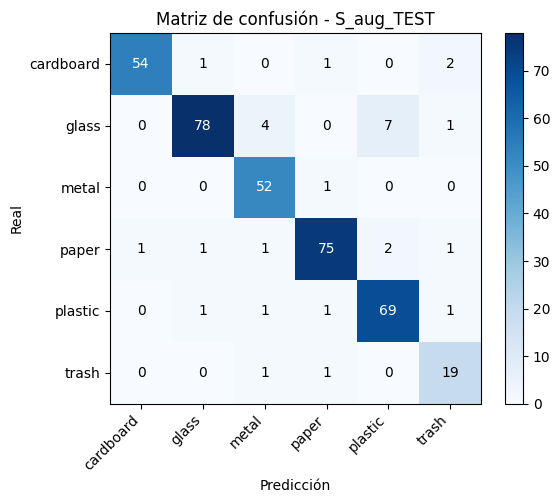

Accuracy final en TEST: 0.9228723404255319


In [5]:
# ESCENARIO CON DATA AUGMENTATION

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# CONFIGURACIÓN GENERAL

data_dir = r"C:\Users\soria\Downloads\Metodología\Clasificacion_residuos"
os.makedirs("Modelos2", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

# TRANSFORMACIONES

# Train → CON augmentation
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Val/Test → SIN augmentation
eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# FUNCIÓN: CARGA Y SPLIT CORRECTO

def cargar_y_dividir_dataset(ruta_carpeta, seed=42):
    """
    Divide el dataset en 70/15/15 usando:
    - Dataset con augmentation para TRAIN
    - Dataset sin augmentation para VAL y TEST
    """

    # Dataset SOLO para obtener índices
    base_dataset = datasets.ImageFolder(ruta_carpeta)
    total = len(base_dataset)

    train_size = int(0.7 * total)
    val_size = int(0.15 * total)
    test_size = total - train_size - val_size

    torch.manual_seed(seed)
    train_idx, val_idx, test_idx = random_split(
        range(total),
        [train_size, val_size, test_size]
    )

    # Datasets reales con transformaciones correctas
    train_dataset = datasets.ImageFolder(
        ruta_carpeta, transform=train_transforms
    )
    eval_dataset = datasets.ImageFolder(
        ruta_carpeta, transform=eval_transforms
    )

    # Subsets
    train_ds = torch.utils.data.Subset(train_dataset, train_idx.indices)
    val_ds   = torch.utils.data.Subset(eval_dataset, val_idx.indices)
    test_ds  = torch.utils.data.Subset(eval_dataset, test_idx.indices)

    # Dataloaders
    train_loader = DataLoader(
        train_ds, batch_size=32, shuffle=True, num_workers=2
    )
    val_loader = DataLoader(
        val_ds, batch_size=32, shuffle=False, num_workers=2
    )
    test_loader = DataLoader(
        test_ds, batch_size=32, shuffle=False, num_workers=2
    )

    class_names = train_dataset.classes

    print(f"Total imágenes: {total}")
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    print(f"Clases: {class_names}")

    return {
        "train": train_loader,
        "val": val_loader,
        "test": test_loader
    }, class_names

# FUNCIÓN: MODELO RESNET-18

def crear_modelo_resnet18(num_classes):
    model = models.resnet18(weights="IMAGENET1K_V1")

    # Fase 1: congelar capas convolucionales
    for p in model.parameters():
        p.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model.to(device)

# FUNCIÓN: ENTRENAMIENTO

def train_model(model, criterion, optimizer, dataloaders, dataset_sizes,
                escenario="Sx", num_epochs=10):

    best_acc = 0.0
    best_wts = model.state_dict()

    print(f"\nIniciando entrenamiento: {escenario}")

    for epoch in range(num_epochs):
        print(f"\nÉpoca {epoch+1}/{num_epochs}")
        print("-" * 30)

        for phase in ["train", "val"]:
            model.train() if phase == "train" else model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase.upper():<5} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_wts = model.state_dict()

    model.load_state_dict(best_wts)

    model_path = f"Modelos2/resnet18_{escenario}.pth"
    torch.save(model.state_dict(), model_path)

    print(f"\nModelo guardado en: {model_path}")
    print(f"Mejor accuracy de validación: {best_acc:.4f}")

    return model

# FUNCIÓN: EVALUACIÓN FINAL

def evaluar_en_test(model, test_loader, class_names, escenario="TEST"):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)

    print(f"\nEvaluación en TEST - {escenario}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(
        y_true, y_pred, target_names=class_names, digits=4
    ))

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(cm, cmap="Blues")
    ax.figure.colorbar(im, ax=ax)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz de confusión - {escenario}")

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, cm[i, j],
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.tight_layout()
    plt.show()

    return acc


# EJECUCIÓN DEL EXPERIMENTO

loaders, class_names = cargar_y_dividir_dataset(
    os.path.join(data_dir, "TrashNet")
)

dataloaders = {
    "train": loaders["train"],
    "val": loaders["val"]
}

dataset_sizes = {
    "train": len(loaders["train"].dataset),
    "val": len(loaders["val"].dataset)
}

model = crear_modelo_resnet18(num_classes=len(class_names))
criterion = nn.CrossEntropyLoss()

# FASE 1: Feature Extraction
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
model = train_model(
    model, criterion, optimizer,
    dataloaders, dataset_sizes,
    escenario="S_aug",
    num_epochs=10
)

# FASE 2: Fine-tuning
for p in model.parameters():
    p.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-4)
model = train_model(
    model, criterion, optimizer,
    dataloaders, dataset_sizes,
    escenario="S_aug_finetuned",
    num_epochs=10
)

# TEST FINAL
test_acc = evaluar_en_test(
    model,
    loaders["test"],
    class_names,
    escenario="S_aug_TEST"
)

print("Accuracy final en TEST:", test_acc)
